In [66]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Notes about mojito noise model:

- The noises are equal, the arm lengths are not
- The test mass ASDs are `3e-15`
- The OMS ASDs are `15e-12`
- No clock noise, no TTL

## instrument config

In [78]:
'''
instru_config = {
    # Random seed
    "seed": 0,
    # Sampling parameters
    "size": instru_size,
    "dt": instru_dt,
    "t0": instru_t0,
    # Physics simulation sampling and filtering
    "physics_upsampling": 4,
    "aafilter": ("kaiser", 240, 1.1, 2.9),
    "noises_f_min_hz": 5e-6,
    # Telemetry sampling
    "telemetry_downsampling": 86400 * 4,
    "initial_telemetry_size": 0,
    # Inter-spacecraft propagation
    "orbits": orbits_file,
    "orbit_dataset": "tcb/ltt",
    "gws": None,
    "interpolation": ("lagrange", 31),
    # Artifacts
    "glitches": None,
    # Laser locking and frequency plan
    "lock": "six",
    "fplan": "static",
    "laser_asds": 0.0,
    "laser_shape": "white",
    "central_freq": 2.816e14,
    "offset_freqs": {
        "12": 0.0,
        "23": 11e6,
        "31": 7.5e6,
        "13": 16e6,
        "32": -12e6,
        "21": -7e6,
    },
    # Laser phase modulation
    "modulation_asds": 0.0,
    "modulation_freqs": 0.0,
    "tdir_modulations": None,
    # Clocks
    "clock_asds": 0.0,
    "clock_offsets": 0.0,
    "clock_freqoffsets": 0.0,
    "clock_freqlindrifts": 0.0,
    "clock_freqquaddrifts": 0.0,
    "clock_f_min_hz": 5e-6,
    # Clock inversion
    "clockinv_tolerance": 1e-10,
    "clockinv_maxiter": 5,
    # Optical pathlength noises
    "backlink_asds": 0.0,
    "backlink_fknees": 0.0,
    "testmass_asds": 3.0e-15,
    "testmass_fknees": 0.4e-3,
    "testmass_fbreak": 8e-3,
    "testmass_frelax": 0.0,
    "testmass_shape": "original",
    "oms_asds": (15.0e-12, 0.0, 0.0, 0.0, 0.0, 0.0),
    "oms_fknees": 2e-3,
    # MOC time correlation
    "moc_time_correlation_asds": 0.0,
    # Tilt-to-length (TTL)
    "ttl_coeffs": (0.0, 0.0, 0.0, 0.0),
    "sc_angular_jitter_asds": (0.0, 0.0, 0.0),
    "sc_angular_jitter_fknees": (0.0, 0.0, 0.0),
    "mosa_angular_jitter_asds": (0.0, 0.0),
    "mosa_angular_jitter_fknees": (0.0, 0.0),
    "mosa_angles": {"12": 30, "23": 30, "31": 30, "13": -30, "32": -30, "21": -30},
    "dws_asds": 0.0,
    # Lateral jitters
    "mosa_longitudinal_jitter_asds": 0.0,
    # Pseudo-ranging
    "ranging_biases": 0,
    "ranging_asds": 0.0,
    "prn_ambiguity": None,
    # Electronic delays
    "electro_delays": (0, 0, 0),
}
'''

'\ninstru_config = {\n    # Random seed\n    "seed": 0,\n    # Sampling parameters\n    "size": instru_size,\n    "dt": instru_dt,\n    "t0": instru_t0,\n    # Physics simulation sampling and filtering\n    "physics_upsampling": 4,\n    "aafilter": ("kaiser", 240, 1.1, 2.9),\n    "noises_f_min_hz": 5e-6,\n    # Telemetry sampling\n    "telemetry_downsampling": 86400 * 4,\n    "initial_telemetry_size": 0,\n    # Inter-spacecraft propagation\n    "orbits": orbits_file,\n    "orbit_dataset": "tcb/ltt",\n    "gws": None,\n    "interpolation": ("lagrange", 31),\n    # Artifacts\n    "glitches": None,\n    # Laser locking and frequency plan\n    "lock": "six",\n    "fplan": "static",\n    "laser_asds": 0.0,\n    "laser_shape": "white",\n    "central_freq": 2.816e14,\n    "offset_freqs": {\n        "12": 0.0,\n        "23": 11e6,\n        "31": 7.5e6,\n        "13": 16e6,\n        "32": -12e6,\n        "21": -7e6,\n    },\n    # Laser phase modulation\n    "modulation_asds": 0.0,\n    "modula

# load noise data

In [70]:
f = h5py.File("./NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5")

In [71]:
fnoise_min = f['noise_estimates/log_frequency_sampling'].attrs['fmin']
fnoise_max = f['noise_estimates/log_frequency_sampling'].attrs['fmax']
fnoise_size = f['noise_estimates/log_frequency_sampling'].attrs['size']
fnoise  = np.geomspace(fnoise_min, fnoise_max, num=fnoise_size)

In [72]:
Cxx = np.array(f['noise_estimates']['XYZ'][0,:,0,0])
Cxy = np.array(f['noise_estimates']['XYZ'][0,:,0,1])
Cxz = np.array(f['noise_estimates']['XYZ'][0,:,0,2])
Cyx = np.array(f['noise_estimates']['XYZ'][0,:,1,0])
Cyy = np.array(f['noise_estimates']['XYZ'][0,:,1,1])
Cyz = np.array(f['noise_estimates']['XYZ'][0,:,1,2])
Czx = np.array(f['noise_estimates']['XYZ'][0,:,2,0])
Czy = np.array(f['noise_estimates']['XYZ'][0,:,2,1])
Czz = np.array(f['noise_estimates']['XYZ'][0,:,2,2])

In [73]:
dataX = np.array(f['tdis/X2'])
dataY = np.array(f['tdis/Y2'])
dataZ = np.array(f['tdis/Z2'])


In [74]:
laser_freq = f.attrs['laser_frequency']
t0 = f['tdis/sampling'].attrs['t0']
dt = f['tdis/sampling'].attrs['dt']
duration = f['tdis/sampling'].attrs['duration']
fs = f['tdis/sampling'].attrs['fs']
size = f['tdis/sampling'].attrs['size']

In [75]:
f.close()

In [76]:
fw, Xw = welch(dataX / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)
fw, Yw = welch(dataY / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)
fw, Zw = welch(dataZ / laser_freq, fs, 'hann', nperseg=256*256*256, noverlap=0)

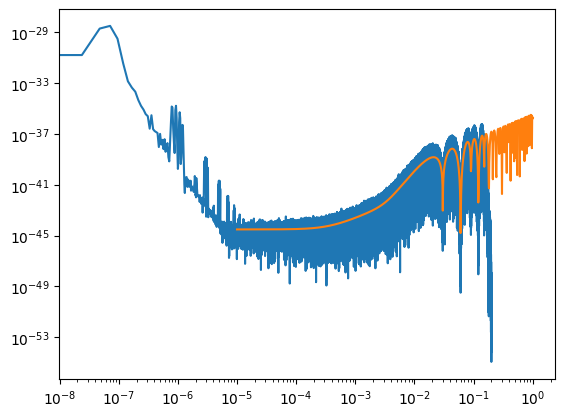

In [77]:
plt.loglog(fw, Xw)
plt.loglog(fnoise, Cxx / laser_freq**2)